### Pipeline context

This notebook is part of the protein design pipeline:

Structure → Design → Validation → Ranking → Optimization

***Select and rank candidates using a design-aware rule***

***Goal***

Create the first  shortlist of redesigned candidates from your validated ProteinMPNN outputs.


***Load the validation table***

In [12]:
import pandas as pd

combined_df = pd.read_csv("../results/tables/design_validation.csv")
combined_df.head()

,name,sequence,num_mutations,mutation_positions,mutations,id,file,plddt,ptm
0,">1LYZ_clean_protein_only, score=1.6112, global...",KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...,0,[],NaN,seq_0,../results/alphafold/seq_0_ce6c6_scores_rank_0...,98.106822,0.91
1,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70,"[1, 2, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,seq_1,../results/alphafold/seq_1_3e80b_scores_rank_0...,96.237209,0.90
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73,"[2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...",V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,seq_2,../results/alphafold/seq_2_a3008_scores_rank_0...,95.363643,0.89
3,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76,"[1, 2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21...",K1M;V2K;F3Y;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L...,seq_3,../results/alphafold/seq_3_76161_scores_rank_0...,91.259147,0.87
4,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70,"[2, 3, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",V2K;F3Y;G4S;A10Q;A11T;M12L;R14K;H15L;L17M;Y20F...,seq_4,../results/alphafold/seq_4_01504_scores_rank_0...,95.135736,0.89


***Separate native from redesigned sequences***

In [13]:
native_df = combined_df[combined_df["num_mutations"] == 0].copy()
designs_df = combined_df[combined_df["num_mutations"] > 0].copy()

print("Native baseline rows:", len(native_df))
print("Redesigned candidate rows:", len(designs_df))

Native baseline rows: 1
Redesigned candidate rows: 5


***Inspect the redesigned candidate regime***

In [14]:
designs_df[["num_mutations", "plddt", "ptm"]].describe()

,num_mutations,plddt,ptm
count,5.000000,5.000000,5.000000
mean,71.200000,94.753054,0.888000
std,3.420526,1.997661,0.010954
min,67.000000,91.259147,0.870000
25%,70.000000,95.135736,0.890000
50%,70.000000,95.363643,0.890000
75%,73.000000,95.769535,0.890000
max,76.000000,96.237209,0.900000


***Define a design-aware selection rule***

In [15]:
selected_df = designs_df[
    (designs_df["plddt"] >= 90) &
    (designs_df["ptm"] >= 0.85) &
    (designs_df["num_mutations"] >= 50)
].copy()

print("Selected redesigned candidates:", len(selected_df))
selected_df

Selected redesigned candidates: 5


,name,sequence,num_mutations,mutation_positions,mutations,id,file,plddt,ptm
1,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70,"[1, 2, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,seq_1,../results/alphafold/seq_1_3e80b_scores_rank_0...,96.237209,0.90
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73,"[2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...",V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,seq_2,../results/alphafold/seq_2_a3008_scores_rank_0...,95.363643,0.89
3,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76,"[1, 2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21...",K1M;V2K;F3Y;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L...,seq_3,../results/alphafold/seq_3_76161_scores_rank_0...,91.259147,0.87
4,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70,"[2, 3, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",V2K;F3Y;G4S;A10Q;A11T;M12L;R14K;H15L;L17M;Y20F...,seq_4,../results/alphafold/seq_4_01504_scores_rank_0...,95.135736,0.89
5,">T=0.1, sample=5, score=0.8566, global_score=0...",MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...,67,"[1, 2, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...",K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...,seq_5,../results/alphafold/seq_5_55760_scores_rank_0...,95.769535,0.89


***Add a ranking score***

In [16]:
selected_df["rank_score"] = (
    selected_df["plddt"] * 0.6 +
    selected_df["ptm"] * 100 * 0.4
)

selected_df = selected_df.sort_values("rank_score", ascending=False).reset_index(drop=True)
selected_df["candidate_rank"] = range(1, len(selected_df) + 1)

selected_df[
    ["candidate_rank", "id", "num_mutations", "plddt", "ptm", "rank_score", "mutations"]
]

,candidate_rank,id,num_mutations,plddt,ptm,rank_score,mutations
0,1,seq_1,70,96.237209,0.90,93.742326,K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...
1,2,seq_5,67,95.769535,0.89,93.061721,K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...
2,3,seq_2,73,95.363643,0.89,92.818186,V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...
3,4,seq_4,70,95.135736,0.89,92.681442,V2K;F3Y;G4S;A10Q;A11T;M12L;R14K;H15L;L17M;Y20F...
4,5,seq_3,76,91.259147,0.87,89.555488,K1M;V2K;F3Y;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L...


***Save the outputs***

In [17]:
native_output = "../results/tables/native_baseline.csv"
selected_output = "../results/tables/selected_candidates.csv"
top3_output = "../results/tables/top3_candidates.csv"

native_df.to_csv(native_output, index=False)
selected_df.to_csv(selected_output, index=False)
selected_df.head(3).to_csv(top3_output, index=False)

print("Saved native baseline to:", native_output)
print("Saved selected candidates to:", selected_output)
print("Saved top 3 candidates to:", top3_output)

Saved native baseline to: ../results/tables/native_baseline.csv
Saved selected candidates to: ../results/tables/selected_candidates.csv
Saved top 3 candidates to: ../results/tables/top3_candidates.csv


***visualization***

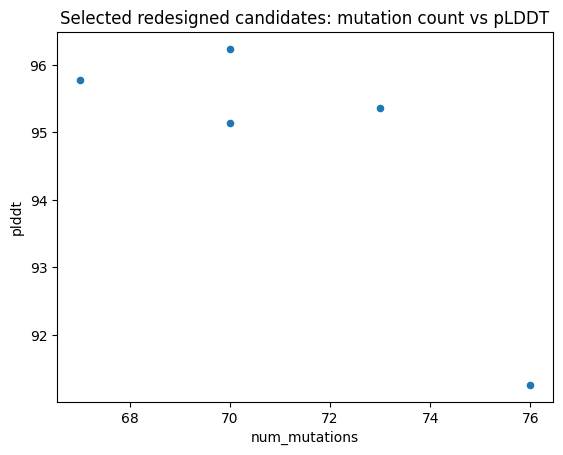

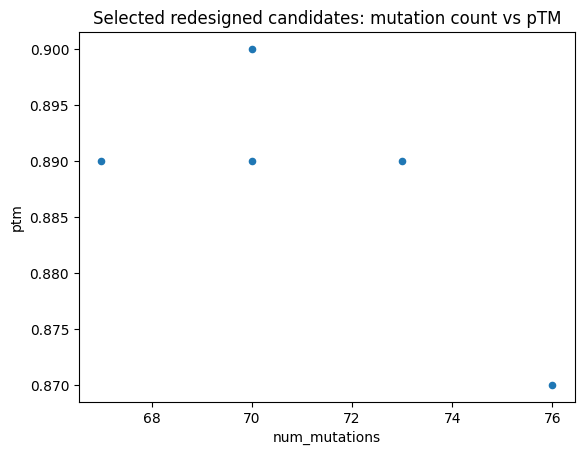

In [18]:
import matplotlib.pyplot as plt

selected_df.plot.scatter(x="num_mutations", y="plddt")
plt.title("Selected redesigned candidates: mutation count vs pLDDT")
plt.show()

selected_df.plot.scatter(x="num_mutations", y="ptm")
plt.title("Selected redesigned candidates: mutation count vs pTM")
plt.show()

## Design-Aware Candidate Selection

The native sequence was separated from redesigned candidates before selection.

### Why this was necessary
ProteinMPNN generated sequences with large numbers of mutations (roughly 60–75), but AlphaFold still predicted high structural confidence. This indicates a high-mutation redesign regime rather than conservative mutation engineering.

### Selection criteria
Redesigned candidates were selected using:
- pLDDT >= 90
- pTM >= 0.85
- num_mutations >= 50

### Ranking logic
Selected designs were ranked using a simple score based on:
- pLDDT
- pTM

### Why this matters
This allows structurally plausible but strongly redesigned candidates to be carried forward, rather than allowing the native sequence to dominate the shortlist.

### Important limitation
This selection step does not yet evaluate function, energetic stability, solvent exposure, or experimental feasibility.

***Compare top designs against the native baseline***

***Load the relevant tables***

In [9]:
import pandas as pd

native_df = pd.read_csv("../results/tables/native_baseline.csv")
selected_df = pd.read_csv("../results/tables/selected_candidates.csv")

***Take top 3 designs***

In [10]:
top3_df = selected_df.head(3).copy()

***Add required columns to BOTH tables***

In [12]:
#for top designs
top3_df["comparison_group"] = "designed"

***for natiev baseline***

In [13]:
native_compare = native_df.copy()

native_compare["comparison_group"] = "native"
native_compare["candidate_rank"] = 0

***add rank_score to native***

Native does not have rank_score → so we define it

In [14]:
native_compare["rank_score"] = (
    native_compare["plddt"] * 0.6 +
    native_compare["ptm"] * 100 * 0.4
)

***checking if all required columns exist***

In [15]:
columns = [
    "comparison_group",
    "candidate_rank",
    "id",
    "num_mutations",
    "plddt",
    "ptm",
    "rank_score",
    "mutations"
]

***align both tables***

In [17]:
native_compare = native_compare[columns]
top3_df = top3_df[columns]

***combine both***

In [18]:
comparison_df = pd.concat([native_compare, top3_df], ignore_index=True)

comparison_df

,comparison_group,candidate_rank,id,num_mutations,plddt,ptm,rank_score,mutations
0,native,0,seq_0,0,98.106822,0.91,95.264093,NaN
1,designed,1,seq_1,70,96.237209,0.90,93.742326,K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...
2,designed,2,seq_5,67,95.769535,0.89,93.061721,K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...
3,designed,3,seq_2,73,95.363643,0.89,92.818186,V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...


***Add sequence divergence label (clean version)***

In [19]:
def classify_divergence(n):
    if n == 0:
        return "native"
    elif n < 10:
        return "low"
    elif n < 30:
        return "moderate"
    elif n < 60:
        return "high"
    else:
        return "very_high"

comparison_df["sequence_divergence"] = comparison_df["num_mutations"].apply(classify_divergence)

comparison_df

,comparison_group,candidate_rank,id,num_mutations,plddt,ptm,rank_score,mutations,sequence_divergence
0,native,0,seq_0,0,98.106822,0.91,95.264093,NaN,native
1,designed,1,seq_1,70,96.237209,0.90,93.742326,K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,very_high
2,designed,2,seq_5,67,95.769535,0.89,93.061721,K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...,very_high
3,designed,3,seq_2,73,95.363643,0.89,92.818186,V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,very_high


***visualization***

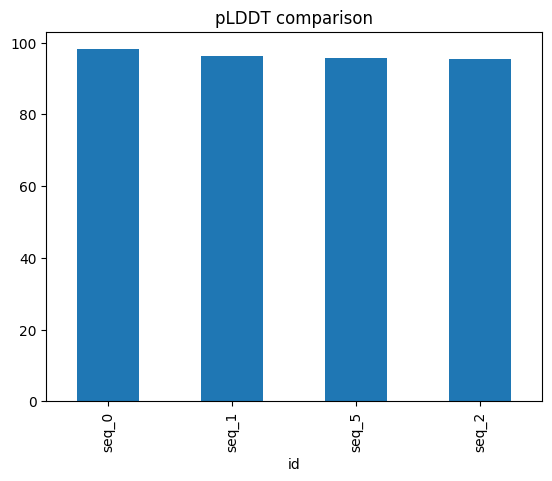

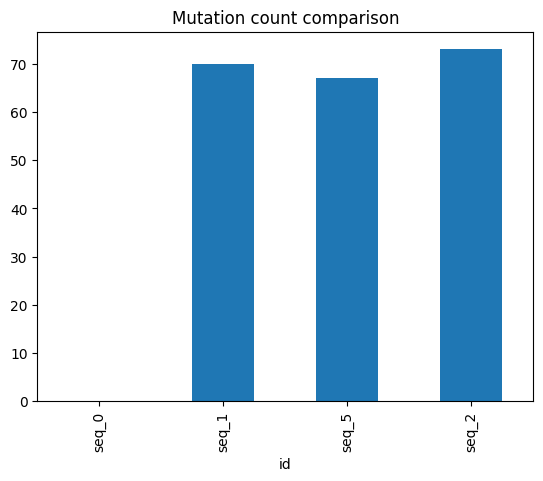

In [20]:
import matplotlib.pyplot as plt

comparison_df.plot.bar(x="id", y="plddt", legend=False)
plt.title("pLDDT comparison")
plt.show()

comparison_df.plot.bar(x="id", y="num_mutations", legend=False)
plt.title("Mutation count comparison")
plt.show()

***save final table***

In [21]:
comparison_df.to_csv("../results/tables/native_vs_top_designs.csv", index=False)

In [22]:
comparison_df

,comparison_group,candidate_rank,id,num_mutations,plddt,ptm,rank_score,mutations,sequence_divergence
0,native,0,seq_0,0,98.106822,0.91,95.264093,NaN,native
1,designed,1,seq_1,70,96.237209,0.90,93.742326,K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...,very_high
2,designed,2,seq_5,67,95.769535,0.89,93.061721,K1M;V2K;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L17M;...,very_high
3,designed,3,seq_2,73,95.363643,0.89,92.818186,V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...,very_high
